# Class Notes: Logistic Regression (18 June 2026)

Topics covered:
1. Why not use linear regression for classification
2. Logistic regression and the sigmoid function
3. Prediction from the sigmoid
4. The cost function
5. Multiple logistic regression
6. Softmax for more than two classes
7. Evaluation: confusion matrix, accuracy, recall, precision, F1, specificity
8. AUC and ROC
9. Precision recall curve

---

In [1]:

# Setup for this notebook
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


## 1. Why Not Linear Regression for Classification

We just spent two days on linear regression, so the natural question is why we cannot reuse it to predict a yes/no label.

Two problems:

- Linear regression outputs any number from minus infinity to plus infinity, but a class probability has to sit between 0 and 1. A straight line will happily predict 1.4 or minus 0.2, which mean nothing as probabilities.
- A single extreme point can tilt the whole line and move the decision boundary, so the fit is fragile for classification.

So we keep the idea of a weighted sum of features but wrap it in a function that squashes the output into the 0 to 1 range. That function is the sigmoid.

---

## 2. Logistic Regression and the Sigmoid

**Logistic regression takes the linear combination `z = b0 + b1*x1 + ... + bn*xn` and passes it through the sigmoid function to produce a probability between 0 and 1.**

Plainly: it is linear regression's straight line fed into a squasher, so the output is always a valid probability.

**The sigmoid function is `sigmoid(z) = 1 / (1 + e^(-z))`.**

```
       1 |            _______
         |         /
     0.5 |•------ /
         |     /
       0 |___/________________
              0            z
```

Why the sigmoid specifically: it maps any real number to (0, 1), it passes through 0.5 at z = 0, and it is smooth, so we can differentiate it for training. Worked values:

```
sigmoid(-2) = 0.1192
sigmoid(-1) = 0.2689
sigmoid( 0) = 0.5000
sigmoid( 1) = 0.7311
sigmoid( 2) = 0.8808
```

(Verified in Python.) Notice it is symmetric around z = 0 and flattens out at both ends, so very large positive or negative z barely change the probability.

### Working of the model: odds and the logit

To see why the sigmoid is the right shape, it helps to know what `z` actually represents.

**The odds of an event are `p / (1 - p)`, and the logit (log odds) is the natural log of the odds. Logistic regression models the logit as a linear function of the features, so `z = log(p / (1-p))`.**

Plainly: the linear part `z` is not the probability, it is the log odds, and the sigmoid is just the inverse that converts log odds back into a probability.

```
p = 0.8  ->  odds = 0.8 / 0.2 = 4.0  ->  logit = ln(4) = 1.3863
```

(Verified in Python.) This is why each coefficient is read on the log odds scale: a one unit change in a feature adds its coefficient to the logit, which multiplies the odds. Running the sigmoid on the logit gets you back to the 0 to 1 probability.

---

sigmoid(-2) = 0.1192
sigmoid(-1) = 0.2689
sigmoid(+0) = 0.5000
sigmoid(+1) = 0.7311
sigmoid(+2) = 0.8808

p = 0.8 -> odds = 4.0 -> logit = ln(odds) = 1.3863


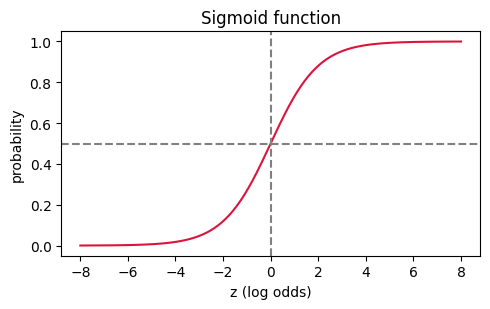

In [2]:
# the sigmoid function: squashes any real number into (0, 1)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for z in [-2, -1, 0, 1, 2]:
    print(f"sigmoid({z:+d}) = {sigmoid(z):.4f}")

# odds and the logit for p = 0.8
p = 0.8
odds = p / (1 - p)
print(f"\np = {p} -> odds = {odds:.1f} -> logit = ln(odds) = {np.log(odds):.4f}")

z = np.linspace(-8, 8, 200)
plt.figure(figsize=(5, 3.2))
plt.plot(z, sigmoid(z), color="crimson")
plt.axhline(0.5, ls="--", color="gray"); plt.axvline(0, ls="--", color="gray")
plt.xlabel("z (log odds)"); plt.ylabel("probability")
plt.title("Sigmoid function"); plt.tight_layout(); plt.show()

## 3. Prediction from the Sigmoid

The sigmoid gives a probability, but a decision needs a class. We apply a threshold.

**The default rule is: predict class 1 if the probability is 0.5 or above, else class 0.**

Plainly: 0.5 is the cutoff by default, which corresponds to z = 0, the middle of the S curve.

The threshold is a choice, not a law. In a medical test where missing a sick patient is far worse than a false alarm, you lower the threshold (say 0.3) so the model flags more people. Tuning this threshold is what the ROC and precision recall curves later are about.

---

## 4. The Cost Function

We cannot reuse squared error here, because pairing the sigmoid with squared error gives a bumpy cost surface with many local minima. We use log loss instead.

**The logistic cost function (log loss, or binary cross entropy) is `-( y*log(p) + (1-y)*log(1-p) )` averaged over all rows, where p is the predicted probability.**

Plainly: when the true label is 1 it only keeps `-log(p)`, and when the true label is 0 it only keeps `-log(1-p)`, so it punishes confident wrong answers very hard.

Worked example for a single row:

```
true y = 1, predicted p = 0.8  ->  loss = -log(0.8) = 0.2231   (small, good)
true y = 1, predicted p = 0.3  ->  loss = -log(0.3) = 1.2040   (large, bad)
true y = 0, predicted p = 0.8  ->  loss = -log(0.2) = 1.6094   (large, bad)
```

(Verified in Python.) The pattern: being confident and right costs almost nothing, being confident and wrong costs a lot. That steep punishment is what pushes the coefficients toward good probabilities during training.

### The Learning Algorithm

**Logistic regression has no closed form solution like linear regression did, so the coefficients are learned iteratively with gradient descent.**

Plainly: there is no single formula to jump straight to the answer, so the model starts with guess coefficients and nudges them step by step in the direction that lowers the log loss.

```
1. Start with initial coefficients (often zeros).
2. Compute the predicted probabilities with the current sigmoid.
3. Compute the log loss and its gradient (which direction reduces it).
4. Nudge each coefficient a small step (the learning rate) down that gradient.
5. Repeat until the loss stops improving.
```

Because log loss is convex for logistic regression, gradient descent is guaranteed to walk toward the single global minimum, so it does not get stuck in a bad local minimum the way squared error paired with a sigmoid would.

---

In [3]:
# log loss punishes confident wrong answers hard
for yt, p in [(1, 0.8), (1, 0.3), (0, 0.8)]:
    loss = -(yt * np.log(p) + (1 - yt) * np.log(1 - p))
    print(f"true y = {yt}, predicted p = {p}  ->  loss = {loss:.4f}")

true y = 1, predicted p = 0.8  ->  loss = 0.2231
true y = 1, predicted p = 0.3  ->  loss = 1.2040
true y = 0, predicted p = 0.8  ->  loss = 1.6094


## 5. Multiple Logistic Regression

Same extension as multiple linear regression: `z` is a weighted sum over many features, then the sigmoid squashes it. Each coefficient is now read on the log odds scale, meaning it tells you how the odds of class 1 shift for a one unit change in that feature, holding the others fixed. The mechanics (fit, threshold, evaluate) are unchanged.

---

## 6. Softmax for More Than Two Classes

Sigmoid handles two classes. For three or more we need a version that spreads probability across all of them.

**Multinomial logistic regression uses the softmax function, which turns a vector of scores into a set of probabilities that are all positive and sum to 1.**

```
softmax(z_i) = e^(z_i) / sum_over_all_j( e^(z_j) )
```

Plainly: exponentiate every class score to make it positive, then divide by the total so the whole set becomes a probability distribution. The class with the highest probability wins.

Worked example with three class scores `[2.0, 1.0, 0.1]`:

```
softmax = [0.6590, 0.2424, 0.0986]   (sums to 1.0)
```

(Verified in Python.) Class 1 gets about 66 percent, and the three add to exactly 1, so it is a proper distribution. Sigmoid is just the two class special case of softmax.

---

In [4]:
# softmax turns class scores into probabilities that sum to 1
logits = np.array([2.0, 1.0, 0.1])
e = np.exp(logits - logits.max())      # subtract max for numerical stability
softmax = e / e.sum()
print("logits :", logits)
print("softmax:", np.round(softmax, 4), " sum =", round(softmax.sum(), 4))

logits : [2.  1.  0.1]
softmax: [0.659  0.2424 0.0986]  sum = 1.0


## 7. Evaluation of a Classification Model

Accuracy alone lies on imbalanced data, so we build up from the confusion matrix.

**The confusion matrix is a table of predicted versus actual labels, split into true positives, true negatives, false positives, and false negatives.**

```
                    Predicted 1     Predicted 0
   Actual 1            TP              FN
   Actual 0            FP              TN

TP: predicted 1, was 1   (correct hit)
TN: predicted 0, was 0   (correct rejection)
FP: predicted 1, was 0   (false alarm,     Type I error)
FN: predicted 0, was 1   (miss,            Type II error)
```

We will use this running confusion matrix for every metric below: `TP=70, TN=50, FP=10, FN=20`.

### Accuracy

**Accuracy is the fraction of all predictions that were correct.**

```
Accuracy = (TP + TN) / (TP + TN + FP + FN) = 120 / 150 = 0.8000
```

(Verified in Python.) The trap: if 95 percent of rows are class 0, a model that always says 0 scores 0.95 accuracy while catching nothing. That is why we need the next two.

### Recall (Sensitivity, True Positive Rate)

**Recall is, of all the actual positives, how many the model caught.**

```
Recall = TP / (TP + FN) = 70 / 90 = 0.7778
```

(Verified in Python.) Recall is the metric you care about when a miss is expensive, like a disease going undetected.

### Precision

**Precision is, of all the times the model predicted positive, how many were actually positive.**

```
Precision = TP / (TP + FP) = 70 / 80 = 0.8750
```

(Verified in Python.) Precision is the metric you care about when a false alarm is expensive, like flagging a good customer as a fraudster.

### The problem, and the tradeoff

You cannot usually max out both. Lowering the threshold catches more positives (recall up) but also raises false alarms (precision down), and raising the threshold does the reverse. This push and pull is why a single blended number is handy.

### F1 Score

**The F1 score is the harmonic mean of precision and recall, a single number that stays low unless both are decent.**

```
F1 = 2 * (precision * recall) / (precision + recall)
   = 2 * (0.875 * 0.7778) / (0.875 + 0.7778) = 0.8235
```

(Verified in Python.) The harmonic mean is used instead of a plain average because it refuses to be fooled by one high value paired with one low value.

### Specificity (True Negative Rate)

**Specificity is, of all the actual negatives, how many the model correctly labeled negative.**

```
Specificity = TN / (TN + FP) = 50 / 60 = 0.8333
```

(Verified in Python.) It is the mirror image of recall, measured on the negative class.

---

In [5]:
# metrics from a worked confusion matrix
TP, TN, FP, FN = 70, 50, 10, 20
accuracy    = (TP + TN) / (TP + TN + FP + FN)
precision   = TP / (TP + FP)
recall      = TP / (TP + FN)
specificity = TN / (TN + FP)
f1          = 2 * precision * recall / (precision + recall)
print(f"TP={TP} TN={TN} FP={FP} FN={FN}")
print(f"Accuracy    = {accuracy:.4f}")
print(f"Precision   = {precision:.4f}")
print(f"Recall      = {recall:.4f}")
print(f"Specificity = {specificity:.4f}")
print(f"F1          = {f1:.4f}")

# the same metrics from a real logistic regression fit
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

data = load_breast_cancer()
Xtr, Xte, ytr, yte = train_test_split(data.data, data.target,
                                      test_size=0.3, random_state=0)
clf = LogisticRegression(max_iter=5000).fit(Xtr, ytr)
pred = clf.predict(Xte)
print("\nReal fit on the breast cancer dataset:")
print("confusion matrix:\n", confusion_matrix(yte, pred))
print(classification_report(yte, pred, digits=3))

TP=70 TN=50 FP=10 FN=20
Accuracy    = 0.8000
Precision   = 0.8750
Recall      = 0.7778
Specificity = 0.8333
F1          = 0.8235



Real fit on the breast cancer dataset:
confusion matrix:
 [[ 62   1]
 [  6 102]]
              precision    recall  f1-score   support

           0      0.912     0.984     0.947        63
           1      0.990     0.944     0.967       108

    accuracy                          0.959       171
   macro avg      0.951     0.964     0.957       171
weighted avg      0.961     0.959     0.959       171



## 8. AUC and ROC

Every metric above depends on the threshold you picked. ROC lets us judge the model across all thresholds at once.

**The ROC curve plots the true positive rate (recall) against the false positive rate (1 minus specificity) as the threshold sweeps from 1 down to 0.**

```
 TPR
  1 |        _____----
    |     _/
    |   /        the closer this curve hugs the top left,
    | /          the better the model
  0 +------------------ FPR
    0                1
    the diagonal dotted line is random guessing (useless)
```

**AUC (Area Under the Curve) is the area under the ROC curve, from 0.5 (random guessing) to 1.0 (perfect).**

Plainly: AUC is the probability that the model scores a random positive higher than a random negative. AUC of 0.5 is a coin flip, 0.8 is decent, 1.0 is perfect separation. Its big advantage is that it does not depend on a single chosen threshold, so it is a fair overall grade.

---

AUC = 0.9963


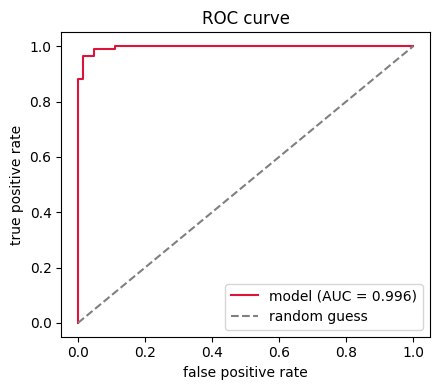

In [6]:
# ROC curve and AUC from the fitted model's predicted probabilities
from sklearn.metrics import roc_curve, roc_auc_score

proba = clf.predict_proba(Xte)[:, 1]
fpr, tpr, _ = roc_curve(yte, proba)
auc = roc_auc_score(yte, proba)
print(f"AUC = {auc:.4f}")

plt.figure(figsize=(4.5, 4))
plt.plot(fpr, tpr, color="crimson", label=f"model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="random guess")
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("ROC curve"); plt.legend(); plt.tight_layout(); plt.show()

## 9. Precision Recall Curve

**The precision recall curve plots precision against recall as the threshold varies.**

Plainly: same sweep idea as ROC, but it focuses only on the positive class.

When to prefer it over ROC: on heavily imbalanced data where positives are rare (fraud, rare disease), ROC can look flatteringly good because the huge negative class keeps the false positive rate low. The precision recall curve does not get that free pass, so it gives a more honest read when the positive class is what you actually care about.

---

## Advantages and Disadvantages of Logistic Regression

Advantages: simple, fast, and highly interpretable (each coefficient is a readable effect on the odds), outputs calibrated probabilities not just labels, and works well when classes are roughly linearly separable.

Disadvantages: it assumes a linear decision boundary, so it underfits genuinely nonlinear patterns, it is sensitive to multicollinearity just like linear regression, and it needs the features engineered sensibly since it will not discover complex interactions on its own.